### Exploratory Data Analysis

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

In [36]:
url = 'https://raw.githubusercontent.com/rrirdr/freight_rate_ml/refs/heads/main/train-test.csv'
df = pd.read_csv(url)
pd.reset_option('display.max_rows')
df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


### Dataset Feature Definitions & Target Guide

* **`load_id`**
  * **Definition:** A unique ID number used to track a specific shipment or job.
  * **Target Guide:** **Neutral** (It is just a text tracking label).

* **`pickup`**
  * **Definition:** The starting city where the truck collects the freight.
  * **Target Guide:** **Neutral** (Categorical location text).

* **`delivery`**
  * **Definition:** The final destination city where the cargo is dropped off.
  * **Target Guide:** **Neutral** (Categorical location text).

* **`pickup_lat` / `pickup_lon`**
  * **Definition:** The precise GPS map coordinates (Latitude and Longitude) for the starting location.
  * **Target Guide:** **Neutral** (Used by models to calculate geographic distance).

* **`delivery_lat` / `delivery_lon`**
  * **Definition:** The precise GPS map coordinates (Latitude and Longitude) for the drop-off location.
  * **Target Guide:** **Neutral** (Used by models to calculate geographic distance).

* **`distance`**
  * **Definition:** The total length of the trip, usually measured in miles.
  * **Target Guide:** **Lower is better for cost.** Shorter trips mean less fuel burned and lower driver wages. (However, *higher is better for revenue* if you are the trucking carrier selling the space).

* **`equipment`**
  * **Definition:** The specific type of truck trailer needed for the job.
    * *Dry Van:* A standard, enclosed box trailer used for everyday dry goods. Lower cost, best for budget.
    * *Reefer:* Short for "Refrigerated Trailer." It has a built-in cooling system to transport temperature-sensitive cargo like fresh food, frozen items, or medicine. Higher Cost, more expensive than dry van.
    * *Flatbed:* An open trailer platform with no sides or roof. It is used to haul heavy, oversized, or oddly shaped cargo—like construction steel, logs, pipes, or heavy machinery—that must be loaded from the side or overhead using cranes or forklifts. Highest cost, most expensive overall.

  * **Target Guide:** **Dry Van is better for cost.** Reefer equipment consumes extra fuel to run the cooling motor and requires more maintenance, making it much more expensive to book.

* **`weight`**
  * **Definition:** The total weight of the cargo, usually measured in pounds (lbs).
  * **Target Guide:** **Lower is better for fuel efficiency.** Heavy trucks burn significantly more fuel and face strict legal highway weight limits.

* **`date`**
  * **Definition:** The scheduled day when the shipment moves.
  * **Target Guide:** **Neutral** (Time-series data used to find seasonal price trends, like holiday rushes).

* **`market_index`**
  * **Definition:** A multiplier comparing current shipping prices to normal historical averages.
  * **Target Guide:** **Lower is better for shippers.** A number below `1.00` means a "buyer's market" where shipping is cheaper than usual. A number above `1.00` means a "seller's market" where trucks are scarce and prices are high.

* **`quote_signal`**
  * **Definition:** A numerical grade evaluating how fast, accurate, and professional the quote process was.
  * **Target Guide:** **Higher is better.** A higher score means the quote was sent out lightning-fast and with total price transparency, resulting in much higher customer trust.

* **`posted_rate`**
  * **Definition:** The final price tag (in dollars) offered to transport the shipment.
  * **Target Guide:** **Lower is better for the shipping customer.** (**Higher is better for the carrier** looking to maximize profits).


In [37]:
rows, columns = df.shape
print('Number of Rows:', rows)
print('Number of Columns:', columns)

Number of Rows: 48000
Number of Columns: 14


In [38]:
df.columns

Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
       'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight',
       'date', 'market_index', 'quote_signal', 'posted_rate'],
      dtype='object')

In [39]:
df.dtypes

load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

In [40]:
df.info() #identified missing data for weight and market_index

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [41]:
with pd.option_context('display.max_rows', None):
    print(df['pickup'].value_counts())

pickup
Oklahoma City     1242
Lexington         1209
Bakersfield       1193
Fort Wayne        1170
Hartford          1150
Richmond          1140
Nashville         1124
Phoenix           1121
Baton Rouge       1115
Mobile            1094
Cincinnati        1080
Shreveport        1062
Kansas City       1053
Columbia          1049
Atlanta           1029
San Antonio        972
Philadelphia       946
Los Angeles        945
Milwaukee          944
Tucson             944
Syracuse           907
Montgomery         884
Greensboro         865
Memphis            852
Charleston         848
Grand Rapids       844
Amarillo           836
Fresno             827
New York           816
Albany             811
Lubbock            796
El Paso            768
Chattanooga        745
Toledo             745
Buffalo            738
Houston            723
Jacksonville       666
Green Bay          662
Reno               642
Tulsa              633
Raleigh            607
Boston             603
Corpus Christi     596
Albu

In [42]:
with pd.option_context('display.max_rows', None):
    print(df['delivery'].value_counts())

delivery
Lexington         1197
Fort Wayne        1176
Baton Rouge       1167
Bakersfield       1156
Hartford          1143
Oklahoma City     1140
Richmond          1109
Atlanta           1096
Phoenix           1090
Mobile            1089
Cincinnati        1084
Columbia          1071
Nashville         1064
Tucson             997
Shreveport         983
Kansas City        980
San Antonio        965
Philadelphia       959
Los Angeles        955
Syracuse           926
Memphis            912
Montgomery         903
Grand Rapids       894
Milwaukee          859
Charleston         851
Amarillo           850
New York           833
Albany             812
Greensboro         804
El Paso            769
Fresno             763
Lubbock            754
Buffalo            753
Jacksonville       746
Houston            718
Toledo             710
Chattanooga        708
Green Bay          660
Raleigh            656
Reno               653
Tulsa              647
Dayton             622
Boston             619
Co

In [43]:
with pd.option_context('display.max_rows', None):
    print(df['equipment'].value_counts())

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


In [44]:
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [45]:
df[df.duplicated()] #checking for duplicate entries
# no duplicate entries observes

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate


In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [47]:
cols_for_histo = df.select_dtypes(include=['float'])
cols_for_histo

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
0,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,0.95684,2.39595,645.41
1,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,0.97623,2.43355,679.97
2,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,1.00971,1.84491,1802.54
3,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,0.94518,1.87712,1827.28
4,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...
47995,39.54838,-118.64843,30.50134,-92.65374,1830.9,31786.0,0.98865,2.05626,3787.32
47996,35.98195,-82.78379,35.56802,-89.52871,445.8,37465.0,1.03034,1.51985,1171.93
47997,35.98195,-82.78379,37.15706,-86.77499,267.9,24528.0,1.00846,1.46954,713.36
47998,35.56802,-89.52871,39.54838,-118.64843,1901.3,37581.0,1.00014,2.05132,3987.46


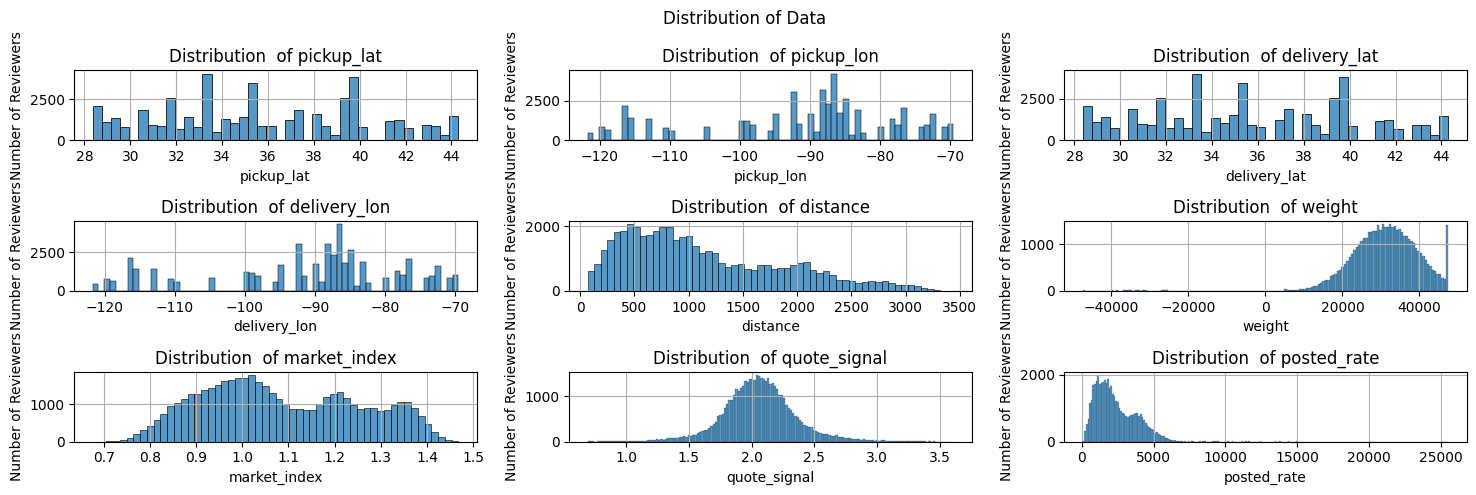

In [48]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,5))
axes = axes.flatten()
for i, column in enumerate(cols_for_histo):
  sns.histplot(data=df, x=column, ax=axes[i])
  axes[i].set_title(f'Distribution  of {column}')
  axes[i].set_xlabel(column)
  axes[i].set_ylabel('Number of Reviewers')
  axes[i].grid(True)

plt.suptitle('Distribution of Data')
plt.tight_layout()
plt.show()

###  Initial Insights from the Data

* The dataset comprises 48,000 rows and 14 features.
* Distances peak under 1,000 miles.
* Weights peak above 20000. Contains negative weight anomalies.
* Market index shows high volatility.
* Quote signal is normally distributed.
* Posted Rate is heavily right-skewed. Mostly under \$2,500 with long tail.

# EDA (Exploratory Data Analysis)

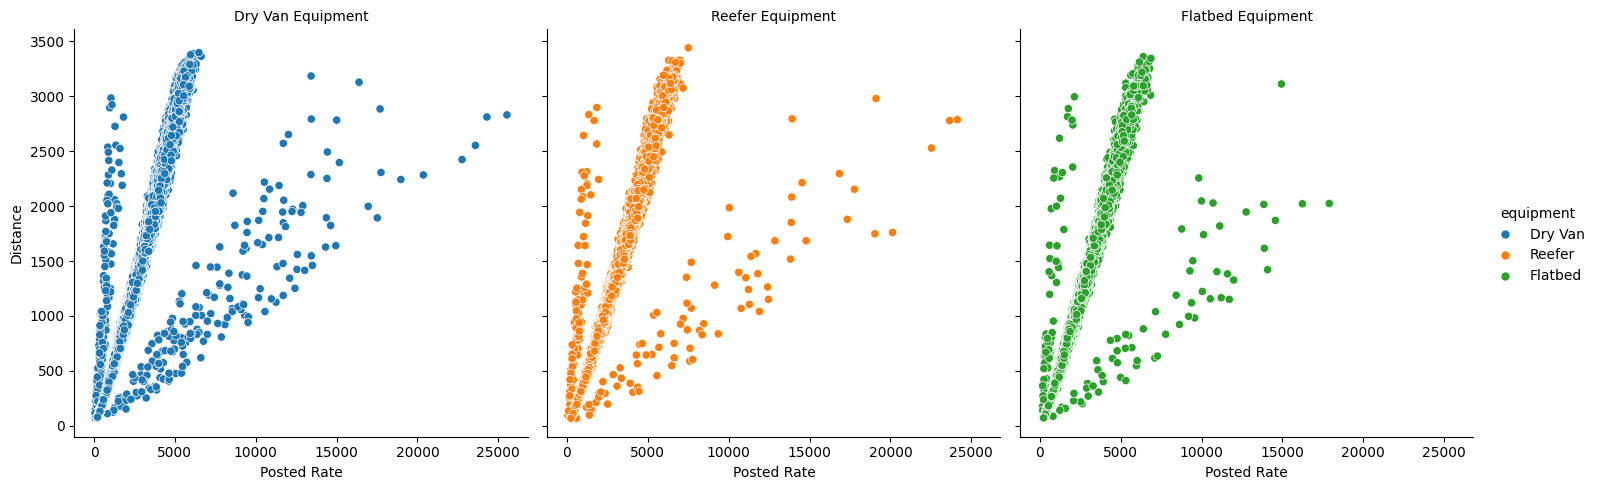

In [ ]:

g = sns.relplot(
    data=df, 
    x='posted_rate', 
    y='distance', 
    hue='equipment', 
    col='equipment',  
    kind='scatter',
    height=5,        
    aspect=1        
)
g.set_axis_labels("Posted Rate", "Distance")
g.set_titles("{col_name} Equipment")
plt.show()


Executive Summary: Pricing Structure by Equipment

The data shows a clear linear relationship between Distance and Posted Rate, split into three distinct pricing tiers starting from zero.
Key Takeaways:

* The Three Market Tiers: Across all equipment, data splits into a low-paying backhaul tier (left line), a standard market tier (dense middle), and a high-paying premium/surge tier (bottom right).
* Dry Vans (Standard Baseline): Holds the highest volume of predictable, standard market jobs. They account for the largest share of extreme long-distance luxury payouts over $20,000.
* Reefers (Refrigerated Premium): The main line sits further to the right than Dry Vans. Temperature-controlled freight demands a clear higher baseline rate per mile.
* Flatbeds (High Volatility): Heavily packed along the low-paying leftmost tier. Flatbed pricing is highly variable and likely depends more on cargo weight than distance.

Text(0.5, 1.0, 'Posted Rate distribution per Equipment')

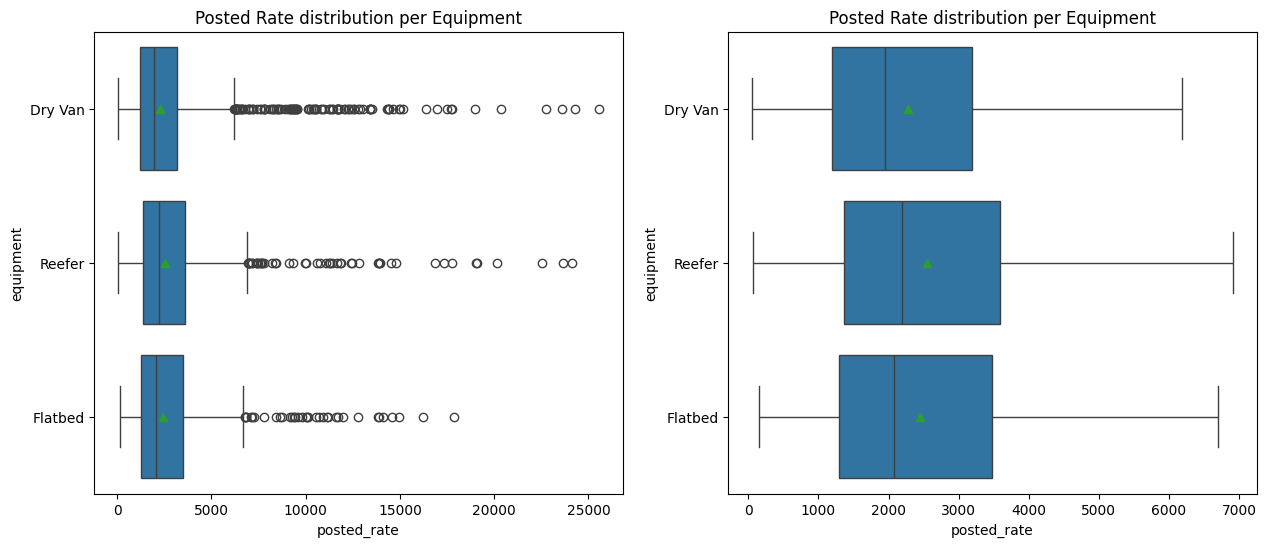

In [50]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

sns.boxplot(ax=axes[0], x='posted_rate', y='equipment', data=df, showmeans=True, legend=False)
axes[0].set_title('Posted Rate distribution per Equipment')

sns.boxplot(ax=axes[1], x='posted_rate', y='equipment', data=df, showmeans=True, showfliers=False ,legend=False)
axes[1].set_title('Posted Rate distribution per Equipment')

These box plots show the spread, average, and middle values of Posted Rates for each equipment type, comparing the full dataset against a cleaned view with outliers removed.

Key Takeaways:
* The Outlier Effect (Left Chart): All three equipment types suffer from extreme high-value outliers reaching up to $25,000. These outliers heavily squeeze the main boxes, making them look deceptively identical at a glance.
* Higher Baseline for Reefers (Right Chart): With outliers removed, Reefer stands out clearly. Its entire box is shifted to the right, showing a higher median (middle line) and a higher mean (green triangle) near $2,500.
* Dry Van vs. Flatbed: Dry Vans have the lowest overall pricing distribution. Flatbeds show slightly higher rate variability, with a wider box stretching towards the higher end of the scale.
* Averages vs. Medians: Across all categories, the mean (green triangle) sits to the right of the median line. This indicates that rates are right-skewed by higher-paying premium jobs.

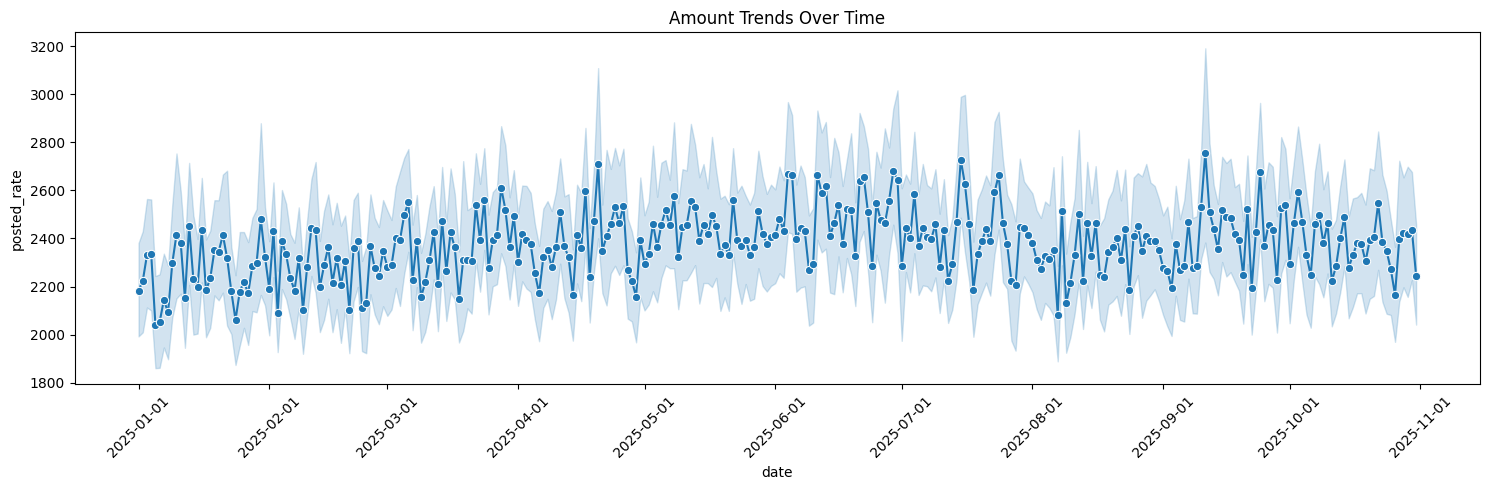

In [56]:
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(15, 5))
sns.lineplot(data=df, x='date', y='posted_rate', marker='o')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title('Amount Trends Over Time')
plt.xticks(rotation=45) 
plt.tight_layout()      
plt.show()

The chart displays daily Posted Rate trends over a 10-month period from January to November 2025, detailing a volatile but cyclical market.

Key Takeaways:

* Stable Core Market: The average baseline rate stays consistently centered between $2,200 and $2,500 across the entire year.
* Mid-Year Surge (Summer Peak): Rates show a steady climbing trend starting in late April, peaking through June and July with more frequent jumps toward $2,600+.
* High Daily Volatility: The shaded blue band represents wide daily fluctuations. Rates regularly swing by $400 to $600 on any given day, showing high short-term price sensitivity.
* Fall Stabilization: Following a brief dip in August, rates stabilize through September and October, returning tightly to their baseline averages

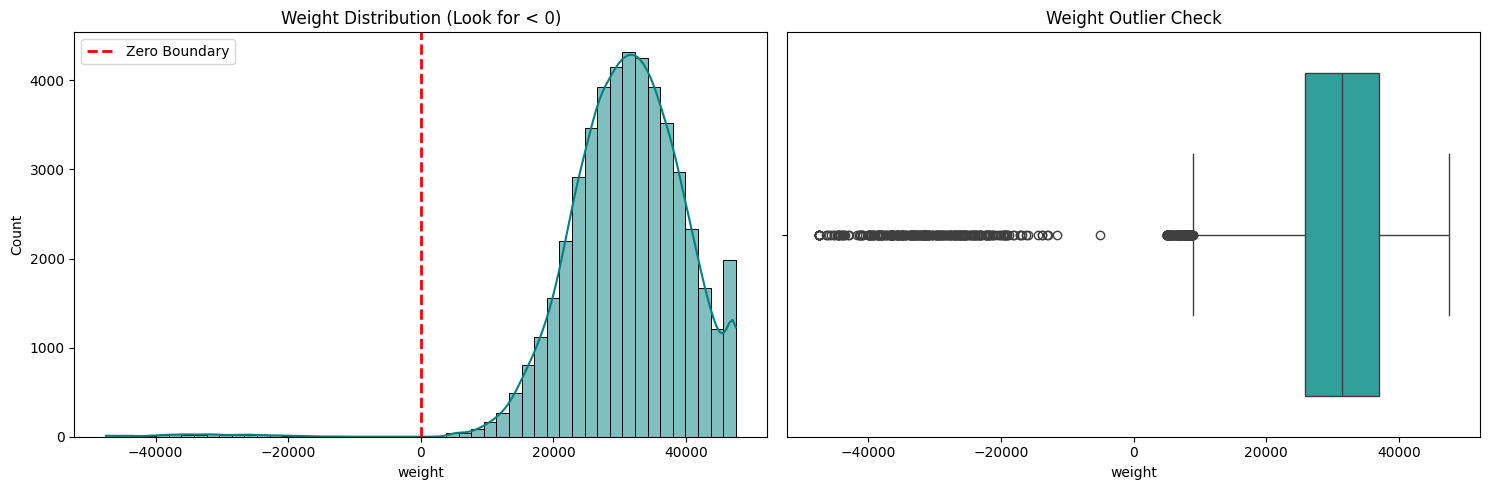

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x='weight', bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Weight Distribution (Look for < 0)')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Boundary')
axes[0].legend()
sns.boxplot(data=df, x='weight', ax=axes[1], color='lightseagreen')
axes[1].set_title('Weight Outlier Check')
plt.tight_layout()
plt.show()

Key Takeaways:

* Negative Weight Violations: The histogram (left) shows a clear tail extending past the red dashed line down to -50,000. Cargo weight cannot be negative. This indicates systematic recording errors or reverse calculation glitches.
* Massive Outlier Cluster: The box plot (right) reveals a dense line of hundreds of individual outlier dots stretching deep into negative territory. These are not random errors; it is a repeated, chronic data bug.

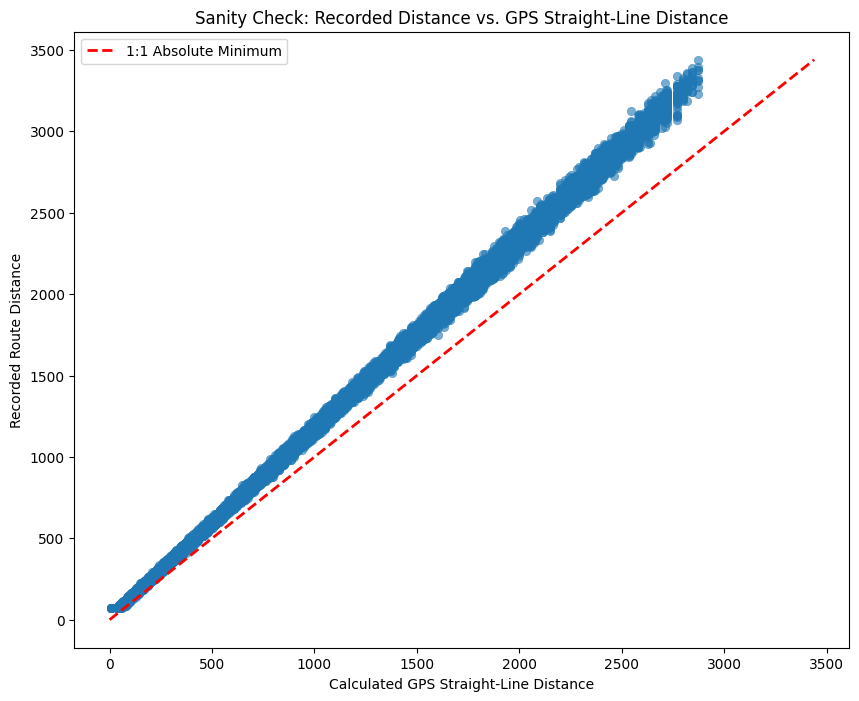

In [60]:
def haversine_np(lon1, lat1, lon2, lat2):
    """Calculate the great circle distance between two points on the earth."""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    miles = km * 0.621371 # Convert to miles (remove '* 0.621371' if your data is in KM)
    return miles

# 1. Calculate the geographic straight-line distance
df['gps_straight_distance'] = haversine_np(
    df['pickup_lon'], df['pickup_lat'], 
    df['delivery_lon'], df['delivery_lat']
)

# 2. Plot recorded distance vs calculated straight-line distance
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='gps_straight_distance', 
    y='distance', 
    alpha=0.6, 
    edgecolor=None
)

# 3. Draw a 1:1 reference line
# (Recorded distance mathematically CANNOT be lower than straight-line distance)
max_val = max(df['gps_straight_distance'].max(), df['distance'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='1:1 Absolute Minimum')

plt.title('Sanity Check: Recorded Distance vs. GPS Straight-Line Distance')
plt.xlabel('Calculated GPS Straight-Line Distance')
plt.ylabel('Recorded Route Distance')
plt.legend()
plt.show()

Key Takeaways:

* Strong Data Validity: All data points sit safely above the red dashed line (1:1 Absolute Minimum). No routes are shorter than straight-line geography, proving there are no impossible distance entries.
* Zero GPS Dropouts: There are no stray dots clustered at 0 on either axis. This means your dataset is free from corrupt default coordinates (like 0.0, 0.0) and broken distance logs.


* K means Cluster on Distance
* Regression or Time Series for Posted Rate
* Perform IQR on posted rate
* https://www.kaggle.com/code/artemyvoronov/agri-trucking-freight-rates-analisys
